# Random Forest Implementation for Lateral Movement Detection

### 0. pip

In [1]:
# you should run this only once - uncomment before first use
%pip install pandas numpy matplotlib scikit-learn joblib tqdm seaborn

Note: you may need to restart the kernel to use updated packages.


### 1. Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from tqdm import tqdm

In [2]:
# File paths
normal_csv_path = r'data\LMD-2023 [2.3M Elements - Normal]checked.csv'
eors_csv_path = r'data\LMD-2023 [2.3M Elements - EORS]checked.csv'
eoht_csv_path = r'data\LMD-2023 [2.3M Elements - EOHT]checked.csv'
preprocessed_data_file = 'checkpointing/rf_preprocessed_data.joblib'
rf_preprocessor_file = 'checkpointing/rf_preprocessor.joblib'
model_file = 'checkpointing/random_forest_model.joblib'

print('Data sources:')
print(f"  Normal: {normal_csv_path}")
print(f"  EORS:   {eors_csv_path}")
print(f"  EOHT:   {eoht_csv_path}")

Data sources:
  Normal: data\LMD-2023 [2.3M Elements - Normal]checked.csv
  EORS:   data\LMD-2023 [2.3M Elements - EORS]checked.csv
  EOHT:   data\LMD-2023 [2.3M Elements - EOHT]checked.csv


### 2. Data Loading & Preprocessing

In [3]:
# Check if preprocessed data exists and matches the expected source
need_reprocess = True
if os.path.exists(preprocessed_data_file):
    try:
        print("Preprocessed data found. Validating source...")
        data = joblib.load(preprocessed_data_file)
        if isinstance(data, dict) and data.get('source') == 'combined':
            X_train, X_test, y_train, y_test = data['X_train'], data['X_test'], data['y_train'], data['y_test']
            need_reprocess = False
            print("Checkpoint source verified: combined datasets.")
            print(f"Training set size: {X_train.shape[0]}")
            print(f"Test set size: {X_test.shape[0]}")
            print(f"Feature dimensions: {X_train.shape[1]}")
        else:
            print("Existing checkpoint not from combined datasets; will reprocess.")
    except Exception as e:
        print(f"Failed to load/validate checkpoint ({e}); will reprocess.")

if need_reprocess:
    print("Preprocessed data not found or invalid. Running full preprocessing pipeline...")
    
    # Load separate Normal and Attack datasets and create labels
    try:
        df_normal = pd.read_csv(normal_csv_path)
        df_eors = pd.read_csv(eors_csv_path)
        df_eoht = pd.read_csv(eoht_csv_path)
        print(f"Loaded {len(df_normal)} normal, {len(df_eors)} EORS, {len(df_eoht)} EOHT records")
    except FileNotFoundError as e:
        print("Error: one of the dataset files not found. Please check the data folder.")
        raise

    # Assign labels: 0 = Normal, 1 = Attack
    df_normal['Label'] = 0
    df_eors['Label'] = 1
    df_eoht['Label'] = 1

    # Combine datasets
    df = pd.concat([df_normal, df_eors, df_eoht], ignore_index=True)
    print(f"Combined dataset shape: {df.shape}")

    # Display label distribution
    print("\nLabel distribution (0=Normal, 1=Attack):")
    print(df['Label'].value_counts())

Preprocessed data found. Validating source...


e:\danny\IDS_using_ML\StackedAEforIDS\.venv\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.0 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Existing checkpoint not from combined datasets; will reprocess.
Preprocessed data not found or invalid. Running full preprocessing pipeline...


C:\Users\broyd\AppData\Local\Temp\ipykernel_4168\1114330873.py:24: DtypeWarning: Columns (39,52,55,56,57,58,59,60,61,64,65,67,68,69,70,71,72,73,74,75,76,77,78,80,81,82,83,84,86,87,88,89,90,91,92) have mixed types. Specify dtype option on import or set low_memory=False.
  df_normal = pd.read_csv(normal_csv_path)
C:\Users\broyd\AppData\Local\Temp\ipykernel_4168\1114330873.py:25: DtypeWarning: Columns (39,40,41,42,43,44,46,47,48,49,51,52,57,58,59,60,70,71,73,74,75,76,77,78,80,81,82,83,84,86,87,88,90,91) have mixed types. Specify dtype option on import or set low_memory=False.
  df_eors = pd.read_csv(eors_csv_path)
C:\Users\broyd\AppData\Local\Temp\ipykernel_4168\1114330873.py:25: DtypeWarning: Columns (39,40,41,42,43,44,46,47,48,49,51,52,57,58,59,60,70,71,73,74,75,76,77,78,80,81,82,83,84,86,87,88,90,91) have mixed types. Specify dtype option on import or set low_memory=False.
  df_eors = pd.read_csv(eors_csv_path)
C:\Users\broyd\AppData\Local\Temp\ipykernel_4168\1114330873.py:26: DtypeWar

Loaded 1632903 normal, 375239 EORS, 135866 EOHT records
Combined dataset shape: (2144008, 95)

Label distribution (0=Normal, 1=Attack):
Label
0    1632903
1     511105
Name: count, dtype: int64
Combined dataset shape: (2144008, 95)

Label distribution (0=Normal, 1=Attack):
Label
0    1632903
1     511105
Name: count, dtype: int64


In [11]:
if need_reprocess:
    selected_features = [
        'DestinationPortName', 'EventID',
        'Execution_ProcessID', 'Initiated', 'ProcessId', 'SourceIsIpv6',
        'SystemTime'
    ]
    
    print(f"Using features: {selected_features}")
    
    # Check if all selected features exist in the dataset
    missing_features = [f for f in selected_features if f not in df.columns]
    if missing_features:
        print(f"Warning: Missing features {missing_features}")
        selected_features = [f for f in selected_features if f in df.columns]
        print(f"Final features: {selected_features}")
    
    # Extract labels
    y = df['Label']
    
    print(f"\nLabel distribution before preprocessing:")
    print(y.value_counts())

Using features: ['DestinationPortName', 'EventID', 'Execution_ProcessID', 'Initiated', 'ProcessId', 'SourceIsIpv6', 'SystemTime']

Label distribution before preprocessing:
Label
0    1632903
1     511105
Name: count, dtype: int64


In [12]:
if need_reprocess:
    # Process SystemTime features similar to AE/VAE
    df['SystemTime'] = pd.to_datetime(df['SystemTime'])
    df['SystemTime_year'] = df['SystemTime'].dt.year
    df['SystemTime_month'] = df['SystemTime'].dt.month
    df['SystemTime_week'] = df['SystemTime'].dt.isocalendar().week
    df['SystemTime_day'] = df['SystemTime'].dt.day
    df['SystemTime_hour'] = df['SystemTime'].dt.hour
    df['SystemTime_minute'] = df['SystemTime'].dt.minute
    df['SystemTime_day_of_week'] = df['SystemTime'].dt.dayofweek
    
    # Create feature list
    time_features = ['SystemTime_year', 'SystemTime_month', 'SystemTime_week', 'SystemTime_day', 'SystemTime_hour', 'SystemTime_minute', 'SystemTime_day_of_week']
    final_features = [f for f in selected_features if f != 'SystemTime'] + time_features
    
    # Select features
    X = df[final_features].copy()
    
    print(f"\nFeature set: {final_features}")
    print(f"Feature matrix shape: {X.shape}")
    
    # Define feature types for preprocessing to match AE/VAE
    categorical_features = ['Computer', 'DestinationPortName', 'EventID', 'Initiated', 'SourceIsIpv6', 'SystemTime_year', 'SystemTime_month', 'SystemTime_week', 'SystemTime_day_of_week']
    numerical_features = ['EventRecordID', 'Execution_ProcessID', 'ProcessId', 'SystemTime_day', 'SystemTime_hour', 'SystemTime_minute']
    
    # Filter features based on what's actually available
    categorical_features = [f for f in categorical_features if f in final_features]
    numerical_features = [f for f in numerical_features if f in final_features]
    
    print(f"Categorical features: {categorical_features}")
    print(f"Numerical features: {numerical_features}")


Feature set: ['DestinationPortName', 'EventID', 'Execution_ProcessID', 'Initiated', 'ProcessId', 'SourceIsIpv6', 'SystemTime_year', 'SystemTime_month', 'SystemTime_week', 'SystemTime_day', 'SystemTime_hour', 'SystemTime_minute', 'SystemTime_day_of_week']
Feature matrix shape: (2144008, 13)
Categorical features: ['DestinationPortName', 'EventID', 'Initiated', 'SourceIsIpv6', 'SystemTime_year', 'SystemTime_month', 'SystemTime_week', 'SystemTime_day_of_week']
Numerical features: ['Execution_ProcessID', 'ProcessId', 'SystemTime_day', 'SystemTime_hour', 'SystemTime_minute']


In [13]:
if need_reprocess:
    # Create preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', MinMaxScaler(), numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ])

    # Ensure categorical types are consistent
    for col in categorical_features:
        if col in X.columns:
            X[col] = X[col].astype(str)

    # Ensure numerical features are numeric
    for col in numerical_features:
        if col in X.columns:
            X[col] = pd.to_numeric(X[col], errors='coerce')
            if X[col].isna().any():
                X[col].fillna(X[col].median(), inplace=True)

    print("\nSplitting data (stratified) and applying preprocessing...")

    # Labels already binary (0/1)
    y_encoded = y.values.astype(int)

    # Split data into train and test sets (80/20 split) using raw features
    X_train_df, X_test_df, y_train, y_test = train_test_split(
        X, y_encoded,
        test_size=0.2,
        random_state=42,
        stratify=y_encoded,
        shuffle=True
    )

    # Fit on train only, transform train and test
    X_train = preprocessor.fit_transform(X_train_df)
    X_test = preprocessor.transform(X_test_df)

    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")
    print(f"Processed feature dimensions: {X_train.shape[1]}")

    # Save preprocessed data and preprocessor
    print("\nSaving preprocessed data and preprocessor...")
    joblib.dump({
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'feature_names': final_features,
        'source': 'combined'
    }, preprocessed_data_file)
    joblib.dump(preprocessor, rf_preprocessor_file)
    print("Preprocessing completed and saved.")


Splitting data (stratified) and applying preprocessing...
Training set: 1715206 samples
Test set: 428802 samples
Processed feature dimensions: 72

Saving preprocessed data and preprocessor...
Preprocessing completed and saved.
Training set: 1715206 samples
Test set: 428802 samples
Processed feature dimensions: 72

Saving preprocessed data and preprocessor...
Preprocessing completed and saved.


### 3. Random Forest Model Implementation

In [14]:
# Random Forest parameters as per the specification
rf_params = {
    'n_estimators': 100,           # Number of trees in the forest
    'max_depth': None,             # Trees grown until all leaves are pure
    'min_samples_split': 2,        # Minimum samples required to split internal node
    'min_samples_leaf': 1,         # Minimum samples required at leaf node
    'criterion': 'gini',           # Gini impurity for split quality
    'random_state': 42,            # For reproducibility
    'n_jobs': -1                   # Use all available cores
}

print("Random Forest Parameters:")
for param, value in rf_params.items():
    print(f"  {param}: {value}")

# Initialize the model
rf_model = RandomForestClassifier(**rf_params)
print(f"\nModel initialized: {rf_model}")

Random Forest Parameters:
  n_estimators: 100
  max_depth: None
  min_samples_split: 2
  min_samples_leaf: 1
  criterion: gini
  random_state: 42
  n_jobs: -1

Model initialized: RandomForestClassifier(n_jobs=-1, random_state=42)


### 4. Training

In [15]:
# Train or load model depending on preprocessing state
if not need_reprocess and os.path.exists(model_file):
    print("Trained model found. Loading...")
    rf_model = joblib.load(model_file)
    print("Model loaded successfully.")
else:
    print("Training Random Forest model...")
    
    # Train the model
    rf_model.fit(X_train, y_train)
    
    print("Training completed.")
    
    # Save the trained model
    print("Saving trained model...")
    joblib.dump(rf_model, model_file)
    print("Model saved successfully.")

# Display model information
print(f"\nModel Details:")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Number of features: {rf_model.n_features_in_}")
print(f"Number of classes: {rf_model.n_classes_}")

Training Random Forest model...
Training completed.
Saving trained model...
Model saved successfully.

Model Details:
Number of trees: 100
Number of features: 72
Number of classes: 2
Training completed.
Saving trained model...
Model saved successfully.

Model Details:
Number of trees: 100
Number of features: 72
Number of classes: 2


### 5. Evaluation

In [16]:
# Evaluation - Clean and Focused (0=Normal, 1=Attack)
print("Making predictions on test set...")
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)

# Core Performance Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print(f"Overall Accuracy: {accuracy:.4f} ({accuracy:.2%})")
print(f"Attack Detection Precision: {precision:.4f}")
print(f"Attack Detection Recall: {recall:.4f}")
print(f"Attack Detection F1-Score: {f1:.4f}")

# Classification Report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

Making predictions on test set...
Overall Accuracy: 0.9985 (99.85%)
Attack Detection Precision: 0.9980
Attack Detection Recall: 0.9957
Attack Detection F1-Score: 0.9968

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    326581
      Attack       1.00      1.00      1.00    102221

    accuracy                           1.00    428802
   macro avg       1.00      1.00      1.00    428802
weighted avg       1.00      1.00      1.00    428802

Overall Accuracy: 0.9985 (99.85%)
Attack Detection Precision: 0.9980
Attack Detection Recall: 0.9957
Attack Detection F1-Score: 0.9968

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    326581
      Attack       1.00      1.00      1.00    102221

    accuracy                           1.00    428802
   macro avg       1.00      1.00      1.00    428802
weighted avg       1.00      1.

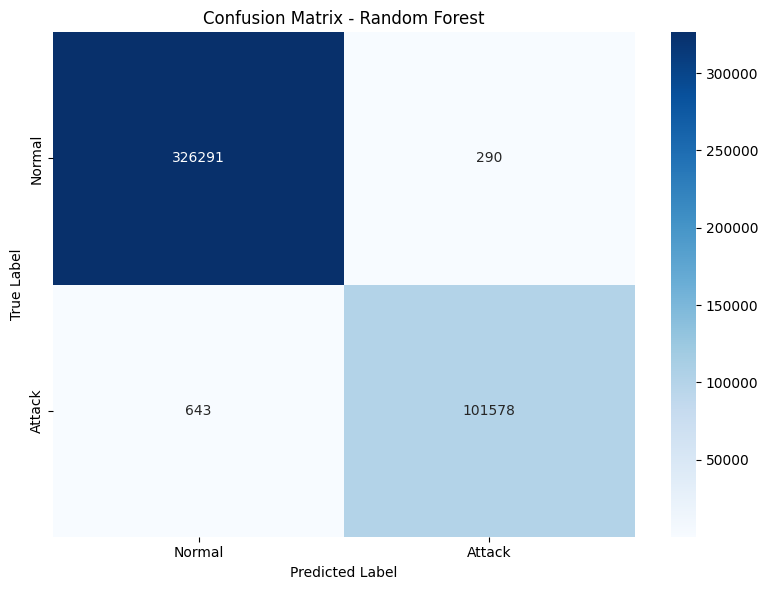


Confusion Matrix Statistics:
True Negatives (Normal correctly classified): 326291
False Positives (Normal misclassified as Attack): 290
False Negatives (Attack misclassified as Normal): 643
True Positives (Attack correctly classified): 101578

Additional Metrics:
Specificity (True Negative Rate): 0.9991
Sensitivity (True Positive Rate): 0.9937
False Positive Rate: 0.0009
False Negative Rate: 0.0063


In [ ]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix - Random Forest (Combined Datasets)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Calculate and display confusion matrix statistics
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Statistics:")
print(f"True Negatives (Normal correctly classified): {tn}")
print(f"False Positives (Normal misclassified as Attack): {fp}")
print(f"False Negatives (Attack misclassified as Normal): {fn}")
print(f"True Positives (Attack correctly classified): {tp}")

# Additional metrics
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\nAdditional Metrics:")
print(f"Specificity (True Negative Rate): {specificity:.4f}")
print(f"Sensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"False Positive Rate: {false_positive_rate:.4f}")
print(f"False Negative Rate: {false_negative_rate:.4f}")

### 6. Feature Importance Analysis

Top 20 Most Important Features:
                             feature  importance
                      num__ProcessId    0.157337
                 num__SystemTime_day    0.104081
                    cat__EventID_3.0    0.091645
             cat__SourceIsIpv6_False    0.089895
                    cat__Initiated_0    0.059364
          cat__DestinationPortName_0    0.045516
                   cat__EventID_10.0    0.044877
                 cat__SourceIsIpv6_0    0.041261
            num__Execution_ProcessID    0.039069
                    cat__EventID_5.0    0.036574
                    cat__EventID_7.0    0.032146
             cat__SystemTime_week_49    0.030156
           cat__SystemTime_year_2022    0.021795
       cat__SystemTime_day_of_week_1    0.019836
cat__DestinationPortName_netbios-dgm    0.014445
             cat__SystemTime_month_9    0.013556
             cat__SystemTime_week_36    0.012536
                   cat__EventID_23.0    0.011569
                num__SystemTime_hour 

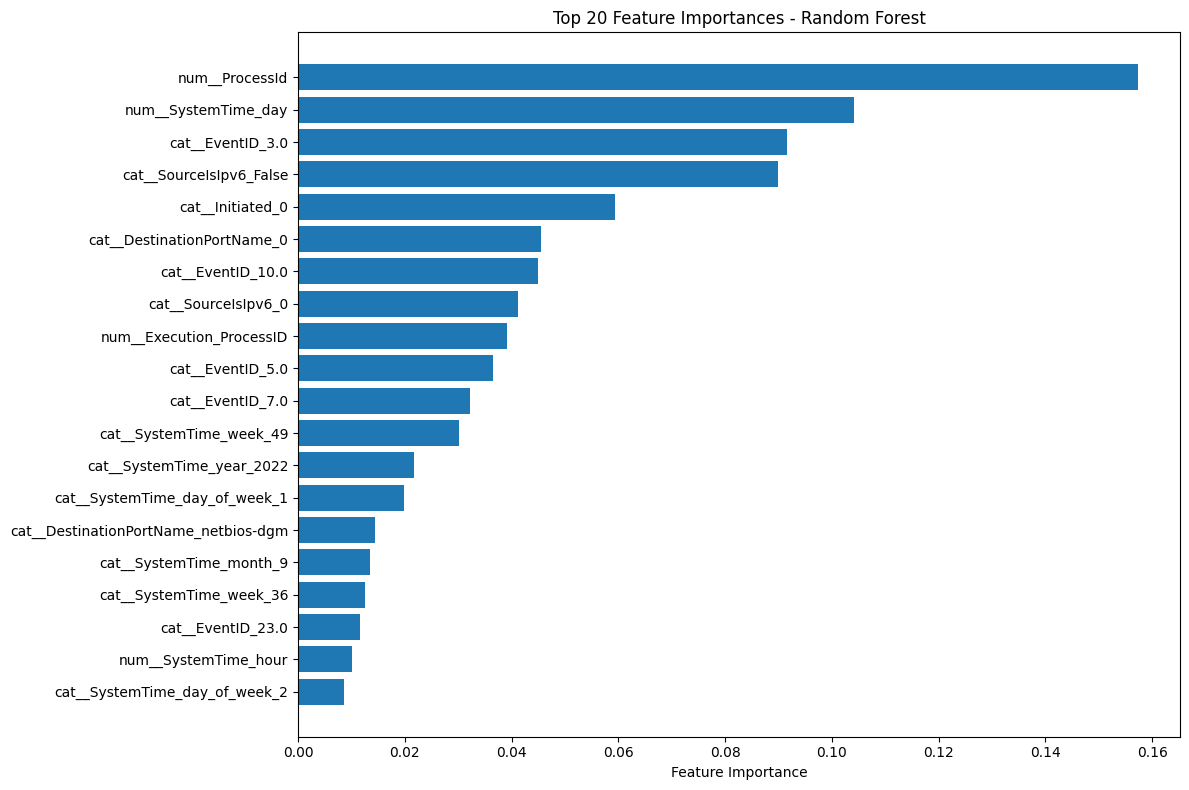

In [17]:
# Feature importance analysis
feature_importance = rf_model.feature_importances_

# Attempt to load feature names from the saved preprocessor
feature_names = None
if os.path.exists(rf_preprocessor_file):
    try:
        saved_preprocessor = joblib.load(rf_preprocessor_file)
        feature_names = saved_preprocessor.get_feature_names_out()
    except Exception as e:
        print(f"Warning: could not load preprocessor feature names: {e}")

# Fallback to generic names
if feature_names is None:
    feature_names = [f'Feature_{i}' for i in range(len(feature_importance))]

# Create feature importance dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Display top 20 most important features
print("Top 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(12, 8))
top_features = importance_df.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 20 Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()